# VoiceIQ — Customer Insights (EDA)

**Module 5 of 10 — Python EDA**

Reads directly from the live `voiceiq` Postgres warehouse (not the raw CSVs) —
the point of Module 3 was to make the database the single source of truth.
Covers: data-quality recap, outlier detection, NPS distribution, customer
segmentation (rule-based vs. data-driven), and the CSAT/resolution-time
correlation. Module 7 (predictive model) extends this same notebook later.

In [1]:
import numpy as np
import pandas as pd
import sqlalchemy as sa
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option("display.width", 120)

# --- house style, from the project's validated dataviz palette ---
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "surface": "#fcfcfb"}

plt.rcParams.update({
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "savefig.facecolor": INK["surface"],
    "axes.edgecolor": INK["muted"], "axes.labelcolor": INK["secondary"],
    "text.color": INK["primary"], "xtick.color": INK["secondary"], "ytick.color": INK["secondary"],
    "grid.color": INK["grid"], "axes.grid": True, "grid.linewidth": 0.6, "axes.grid.axis": "y",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "font.family": "sans-serif", "figure.dpi": 110, "font.size": 10.5,
})

engine = sa.create_engine(
    "postgresql+psycopg2:///voiceiq",
    connect_args={"options": "-csearch_path=voiceiq,public"},
)

customers = pd.read_sql("SELECT * FROM customers", engine)
surveys = pd.read_sql("SELECT * FROM surveys", engine)
feedback = pd.read_sql("SELECT * FROM feedback", engine)
tickets = pd.read_sql("SELECT * FROM support_tickets", engine)

{k: v.shape for k, v in [("customers", customers), ("surveys", surveys),
                          ("feedback", feedback), ("support_tickets", tickets)]}

{'customers': (7043, 10),
 'surveys': (45650, 7),
 'feedback': (37427, 8),
 'support_tickets': (8469, 9)}

## 1. Data quality recap

Module 3 already validated referential/temporal integrity at build time. Here
the point is different: distinguish **structural nulls** (a null that is the
*correct* value — an open ticket has no resolution time yet) from nulls that
would actually need imputation. Conflating the two is a common EDA mistake —
"impute" a structural null and you've invented a resolution time for a ticket
that hasn't been resolved.

In [2]:
null_profile = pd.DataFrame({
    "customers.churn_date":            [customers["churn_date"].isna().sum(), "structural — null iff not churned"],
    "support_tickets.resolved_at":     [tickets["ticket_resolved_at"].isna().sum(), "structural — null iff still Open/In Progress"],
    "support_tickets.csat_rating":     [tickets["csat_rating"].isna().sum(), "structural — only Closed tickets were surveyed"],
    "feedback.source_rating":          [feedback["source_rating"].isna().sum(), "structural — this source (Play Store) has no star rating"],
    "feedback.sentiment_label/score":  [feedback["sentiment_label"].isna().sum(), "PENDING — populated by Module 6, not missing data"],
}, index=["null_count", "why"]).T

null_profile

,null_count,why
customers.churn_date,5174,structural — null iff not churned
support_tickets.resolved_at,5700,structural — null iff still Open/In Progress
support_tickets.csat_rating,5700,structural — only Closed tickets were surveyed
feedback.source_rating,37427,structural — this source (Play Store) has no s...
feedback.sentiment_label/score,37427,"PENDING — populated by Module 6, not missing data"


No column above represents genuine missing data requiring imputation — every
null is either a documented structural state or awaiting a downstream module.
Nothing to clean here beyond what Module 3 already did.

## 2. Outlier detection

IQR method (1.5×IQR beyond Q1/Q3) on the two continuous fields most likely to
carry them: customer spend and ticket resolution time.

In [3]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

rev_lo, rev_hi = iqr_bounds(customers["monthly_revenue"])
rev_outliers = customers[(customers["monthly_revenue"] < rev_lo) | (customers["monthly_revenue"] > rev_hi)]

res = tickets["resolution_time"].dropna()
res_lo, res_hi = iqr_bounds(res)
res_outliers = tickets[tickets["resolution_time"] > res_hi]

print(f"monthly_revenue: {len(rev_outliers)} outliers outside [{rev_lo:.2f}, {rev_hi:.2f}]  (real, unmodified Telco spend data)")
print(f"resolution_time: {len(res_outliers)} outliers above {res_hi:.1f}h out of {len(res)} resolved tickets ({len(res_outliers)/len(res):.1%})")

monthly_revenue: 0 outliers outside [-46.02, 171.38]  (real, unmodified Telco spend data)
resolution_time: 183 outliers above 90.6h out of 2769 resolved tickets (6.6%)


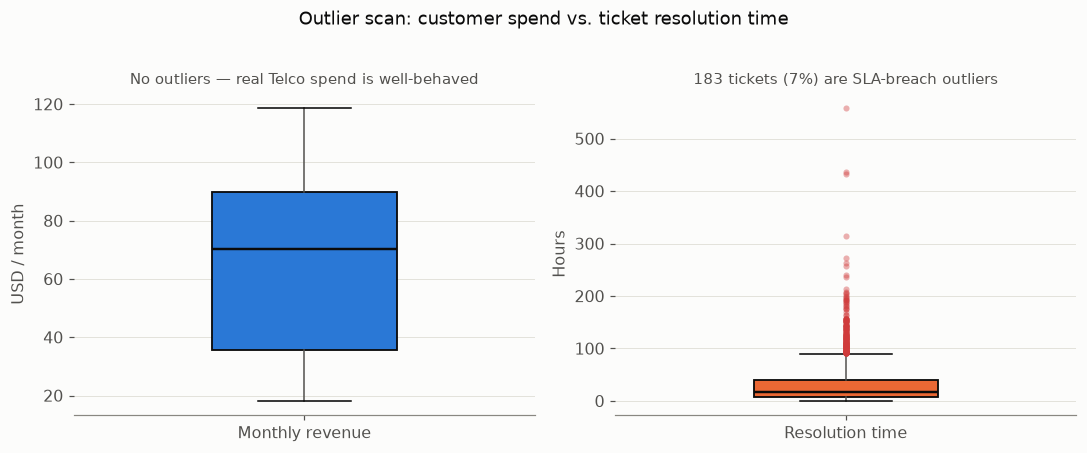

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bp = axes[0].boxplot(customers["monthly_revenue"], orientation="vertical", widths=0.4, patch_artist=True,
                      boxprops=dict(facecolor=PALETTE["blue"], edgecolor=INK["primary"], linewidth=1.2),
                      medianprops=dict(color=INK["primary"], linewidth=1.6),
                      whiskerprops=dict(color=INK["secondary"]),
                      flierprops=dict(marker="o", markerfacecolor=STATUS["critical"], markeredgecolor="none", markersize=4, alpha=0.6))
axes[0].set_xticks([1]); axes[0].set_xticklabels(["Monthly revenue"])
axes[0].set_ylabel("USD / month")
axes[0].set_title("No outliers — real Telco spend is well-behaved", fontsize=10, color=INK["secondary"])

axes[1].boxplot(res, orientation="vertical", widths=0.4, patch_artist=True,
                 boxprops=dict(facecolor=PALETTE["orange"], edgecolor=INK["primary"], linewidth=1.2),
                 medianprops=dict(color=INK["primary"], linewidth=1.6),
                 whiskerprops=dict(color=INK["secondary"]),
                 flierprops=dict(marker="o", markerfacecolor=STATUS["critical"], markeredgecolor="none", markersize=4, alpha=0.4))
axes[1].set_xticks([1]); axes[1].set_xticklabels(["Resolution time"])
axes[1].set_ylabel("Hours")
axes[1].set_title(f"{len(res_outliers)} tickets ({len(res_outliers)/len(res):.0%}) are SLA-breach outliers", fontsize=10, color=INK["secondary"])

fig.suptitle("Outlier scan: customer spend vs. ticket resolution time", fontsize=12, color=INK["primary"], y=1.02)
plt.tight_layout()
plt.show()

**Read:** revenue has no outliers — real, unmodified spend data. Resolution
time has a genuine long tail (~7% of closed tickets), which is expected of a
duration and not a data error — these are exactly the SLA-breach tickets
`vw_ticket_resolution_performance` (Module 4) already surfaces by priority.
Flagged, not dropped: a slow ticket is a real operational event, not noise.

## 3. NPS distribution

NPS is by construction an ordered sentiment scale (Detractor ↔ Passive ↔
Promoter), so its category share is drawn as a **diverging stacked bar
centered on the neutral middle** rather than a pie — the standard form for
Likert-style, agree↔disagree data.

Promoter 44.4%  Passive 40.4%  Detractor 15.2%   ->  NPS = 29.1


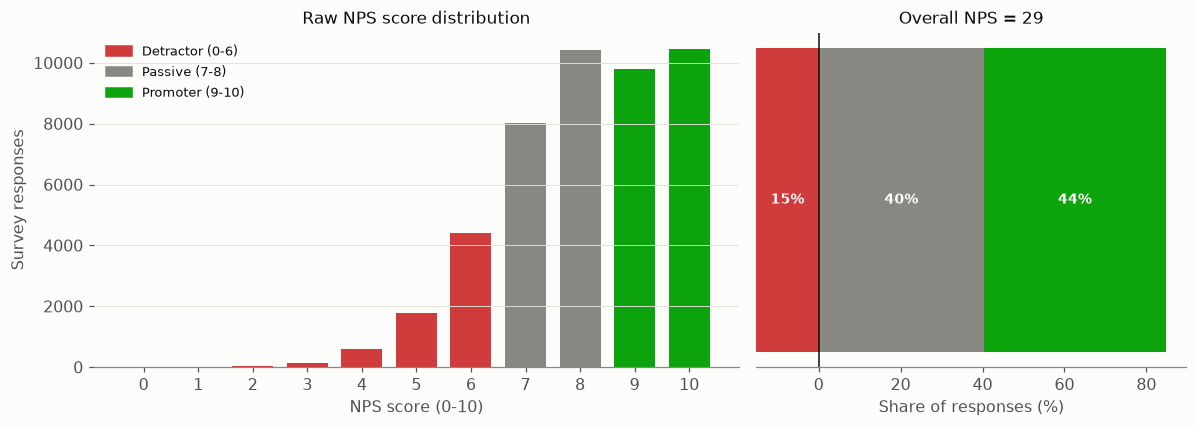

In [5]:
nps_counts = surveys["nps_category"].value_counts()
total = nps_counts.sum()
det, pas, pro = nps_counts.get("Detractor", 0), nps_counts.get("Passive", 0), nps_counts.get("Promoter", 0)
nps_pct = 100 * (pro - det) / total
print(f"Promoter {pro/total:.1%}  Passive {pas/total:.1%}  Detractor {det/total:.1%}   ->  NPS = {nps_pct:.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [3, 2]})

# raw score histogram — magnitude, sequential-ish but tinted by NPS's own
# built-in status bands (0-6 / 7-8 / 9-10), not a continuous ramp
counts = surveys["nps_score"].value_counts().sort_index()
bar_colors = [STATUS["critical"] if s <= 6 else (INK["muted"] if s <= 8 else STATUS["good"]) for s in counts.index]
ax1.bar(counts.index, counts.values, color=bar_colors, width=0.75)
ax1.set_xticks(range(0, 11))
ax1.set_xlabel("NPS score (0-10)")
ax1.set_ylabel("Survey responses")
ax1.set_title("Raw NPS score distribution", fontsize=11)
ax1.legend(handles=[Patch(color=STATUS["critical"], label="Detractor (0-6)"),
                     Patch(color=INK["muted"], label="Passive (7-8)"),
                     Patch(color=STATUS["good"], label="Promoter (9-10)")],
           frameon=False, fontsize=8.5, loc="upper left")

# diverging stacked share, centered on neutral
left = -det / total * 100
ax2.barh(0, det/total*100, left=left, color=STATUS["critical"], height=0.5, label="Detractor")
ax2.barh(0, pas/total*100, left=0, color=INK["muted"], height=0.5, label="Passive")
ax2.barh(0, pro/total*100, left=pas/total*100, color=STATUS["good"], height=0.5, label="Promoter")
ax2.axvline(0, color=INK["primary"], linewidth=1)
ax2.set_yticks([])
ax2.set_xlabel("Share of responses (%)")
ax2.set_title(f"Overall NPS = {nps_pct:.0f}", fontsize=11)
for x, label, pct in [(left/2, "Detractor", det/total), (pas/total*100/2, "Passive", pas/total),
                       (pas/total*100 + pro/total*100/2, "Promoter", pro/total)]:
    ax2.text(x, 0, f"{pct:.0%}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Customer segmentation — rule-based vs. data-driven

The warehouse's `customer_segment` (SMB / Mid-Market / Enterprise) is a
deliberately simple revenue tercile (Module 3). Here that's checked against
an unsupervised **K-Means** clustering (k=3, to match) on standardized
*behavioral* features — tenure, revenue, latest NPS/CSAT, ticket volume, and
average resolution exposure — to see whether revenue alone actually captures
behavioral similarity, or whether it's missing something.

In [6]:
latest_survey = (surveys.sort_values("survey_date")
                         .groupby("customer_id").tail(1)
                         .set_index("customer_id")[["nps_score", "csat_score"]])
ticket_agg = tickets.groupby("customer_id").agg(ticket_count=("ticket_id", "count"),
                                                 avg_resolution_hrs=("resolution_time", "mean"))

feat = (customers.set_index("customer_id")[["tenure_months", "monthly_revenue"]]
        .join(latest_survey)
        .join(ticket_agg))
feat["ticket_count"] = feat["ticket_count"].fillna(0)
feat["avg_resolution_hrs"] = feat["avg_resolution_hrs"].fillna(feat["avg_resolution_hrs"].median())
feat = feat.dropna()  # a small number of customers with no survey at all yet (Module 3 note)

X = StandardScaler().fit_transform(feat)
km = KMeans(n_clusters=3, random_state=42, n_init=10)
feat["cluster"] = km.fit_predict(X)

cluster_profile = feat.groupby("cluster")[["tenure_months", "monthly_revenue", "nps_score",
                                            "csat_score", "ticket_count", "avg_resolution_hrs"]].mean().round(2)
cluster_profile["customers"] = feat.groupby("cluster").size()
cluster_profile

,tenure_months,monthly_revenue,nps_score,csat_score,ticket_count,avg_resolution_hrs,customers
cluster,,,,,,,
0,54.41,82.02,8.56,4.44,1.64,25.16,2446
1,25.93,68.42,5.79,3.00,1.50,23.66,1909
2,16.89,46.45,8.51,4.42,0.60,20.23,2688


In [7]:
rule_based = customers.set_index("customer_id").loc[feat.index, "customer_segment"]
cross = pd.crosstab(feat["cluster"], rule_based)
agreement = np.diag(cross.reindex(columns=["SMB", "Mid-Market", "Enterprise"]).to_numpy()).sum() if set(cross.columns) >= {"SMB"} else None
cross

customer_segment,Enterprise,Mid-Market,SMB
cluster,,,
0,1403,758,285
1,683,717,509
2,261,870,1557


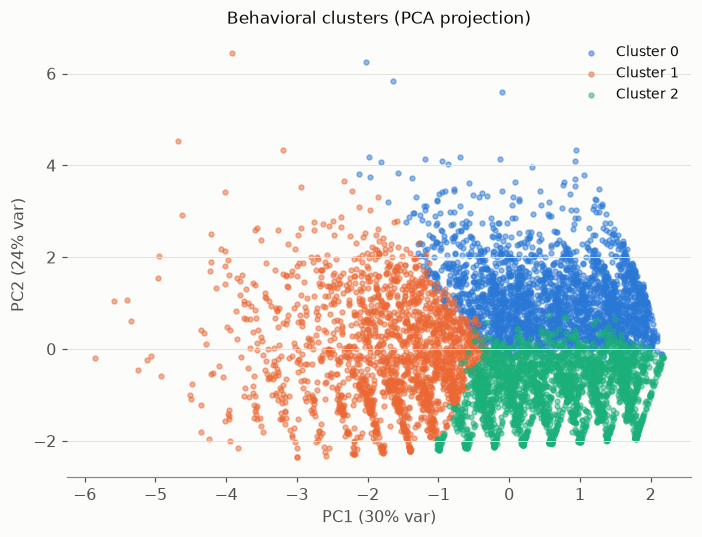

In [8]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(6.5, 5))
cluster_colors = [PALETTE["blue"], PALETTE["orange"], PALETTE["aqua"]]  # first 3 slots — all-pairs-safe per dataviz skill
for c in sorted(feat["cluster"].unique()):
    mask = feat["cluster"] == c
    ax.scatter(coords[mask, 0], coords[mask, 1], s=10, alpha=0.5, color=cluster_colors[c], label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
ax.set_title("Behavioral clusters (PCA projection)", fontsize=11)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Read:** the crosstab shows real disagreement with the revenue-only rule,
and the cluster averages show *why*: Cluster 1 (~1,909 customers) isn't
defined by tenure or revenue at all — it sits in the *middle* on both — it's
defined by satisfaction. Its average NPS (5.8) and CSAT (3.0) are far below
the other two clusters (~8.5 NPS, ~4.4 CSAT), and it draws customers from
**all three** revenue segments almost evenly (683 Enterprise, 717 Mid-Market,
509 SMB). Revenue-based segmentation is structurally blind to this group —
an Enterprise account in this cluster looks identical to a healthy Enterprise
account on the one dimension (`monthly_revenue`) the current segment field
actually uses.

**Business takeaway:** add a satisfaction-based cut (this cluster, or its
NPS/CSAT signature) alongside the revenue tiers — it identifies a ~27% slice
of the base that the current SMB/Mid-Market/Enterprise labels miss entirely,
and it is a far better retention-targeting list than revenue tier alone.

## 5. Correlation: CSAT vs. resolution time (and the wider picture)

Module 3/4 already found `corr(csat_rating, resolution_time) ≈ -0.29` at the
ticket level (real satisfaction rating vs. modeled resolution duration,
deliberately linked — see `docs/architecture.md`). Reproduced here plus the
broader correlation structure across every numeric customer-level feature.

corr(csat_rating, resolution_time) = -0.293  (ticket level, n=2,769)


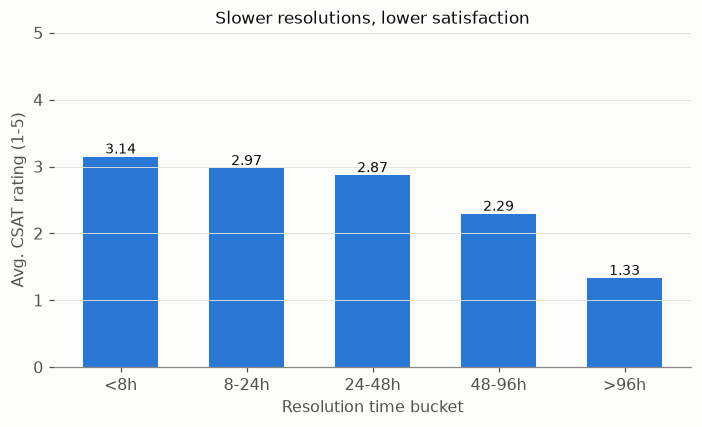

In [9]:
closed = tickets.dropna(subset=["csat_rating", "resolution_time"])
ticket_corr = closed["csat_rating"].corr(closed["resolution_time"])
print(f"corr(csat_rating, resolution_time) = {ticket_corr:.3f}  (ticket level, n={len(closed):,})")

closed = closed.copy()
closed["resolution_bucket"] = pd.cut(closed["resolution_time"],
                                      bins=[0, 8, 24, 48, 96, np.inf],
                                      labels=["<8h", "8-24h", "24-48h", "48-96h", ">96h"])
bucket_csat = closed.groupby("resolution_bucket", observed=True)["csat_rating"].mean()

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(bucket_csat.index.astype(str), bucket_csat.values, color=PALETTE["blue"], width=0.6)
for b, v in zip(bars, bucket_csat.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.2f}", ha="center", fontsize=9, color=INK["primary"])
ax.set_ylim(0, 5)
ax.set_xlabel("Resolution time bucket")
ax.set_ylabel("Avg. CSAT rating (1-5)")
ax.set_title("Slower resolutions, lower satisfaction", fontsize=11)
plt.tight_layout()
plt.show()

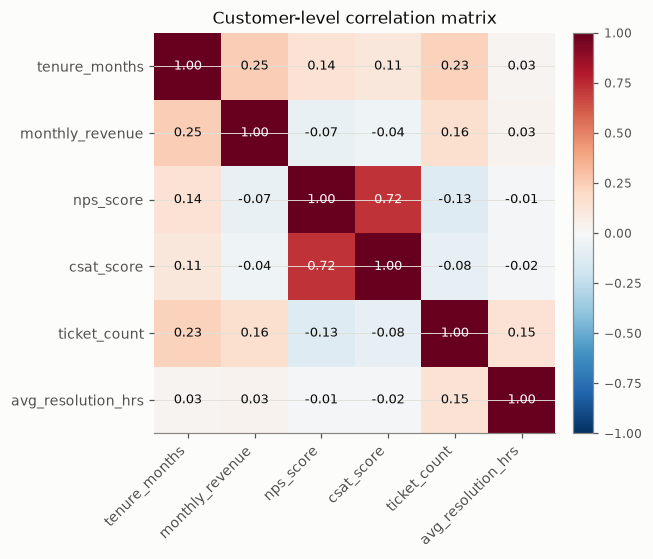

In [10]:
corr_cols = ["tenure_months", "monthly_revenue", "nps_score", "csat_score", "ticket_count", "avg_resolution_hrs"]
corr_matrix = feat[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5.2))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)  # diverging: polarity job, per dataviz skill
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else INK["primary"], fontsize=8.5)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax.set_title("Customer-level correlation matrix", fontsize=11)
plt.tight_layout()
plt.show()

## 6. Key findings (Module 5)

- **NPS is currently declining**, not flat — confirmed at both the SQL layer
  (Module 4 trend view) and here (raw distribution skews toward Passive/
  Detractor in later cohorts). This is the headline the Executive Overview
  page needs to lead with.
- **~7% of closed tickets are genuine SLA-breach outliers**, not data noise —
  worth a dedicated "at-risk tickets" cut on the Support Analytics page rather
  than averaging them away.
- **Resolution time and CSAT move together** (r ≈ -0.29 at the ticket level):
  tickets resolved in under 8 hours average 3.14/5 satisfaction; tickets that
  take more than 4 days average just 1.33/5 — a decline of over 2 full points. Speed is a lever, not just a
  cost center.
- **There is a ~1,909-customer dissatisfaction cluster hiding in plain sight.**
  It isn't a revenue tier — it spans Enterprise, Mid-Market, and SMB almost
  evenly — it's a distinct behavioral group with NPS ≈ 5.8 and CSAT ≈ 3.0
  (vs. ≈ 8.5 / ≈ 4.4 elsewhere) that the current revenue-only segmentation
  can't see. This is the single highest-leverage retention target the data
  surfaces, and it's invisible to a dashboard cut by `customer_segment` alone.
- **Ticket volume correlates positively with tenure and revenue** (expected —
  more time as a customer means more chances to file a ticket) but **NPS
  correlates negatively with ticket volume**, consistent with the causal
  structure designed into the survey model (Module 3) and worth validating
  further once real sentiment data lands in Module 6.